In [1]:
import warnings
import torch
import torch.nn as nn
import pandas as pd
from torch_geometric.loader import DataLoader
from torch_geometric.nn.models import GCN
from CHILI_centralAtoms import CHILI

In [2]:
root = 'data'
dataset='CHILI-3K'
dataset = CHILI(root, dataset,graph_type='central', pre_transform=None, pre_filter=None)

In [3]:
# Hyperparamters
learning_rate = 0.001
batch_size = 16
max_epochs = 10
seeds = 42
max_patience = 50  # Epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    dataset.create_data_split(split_strategy = 'random', test_size=0.1)
    dataset.load_data_split(split_strategy = 'random')
    
# Define dataloaders
train_loader = DataLoader(dataset.train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset.validation_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset.test_set, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(dataset.train_set)}", flush=True)
print(f"Number of validation samples: {len(dataset.validation_set)}", flush=True)
print(f"Number of test samples: {len(dataset.test_set)}", flush=True)

Generating statistics for full graph...:   0%|          | 0/3160 [00:00<?, ?it/s]

Generating statistics for unit_cell graph...:   0%|          | 0/3160 [00:00<?, ?it/s]

Generating statistics for central graph...:   0%|          | 0/3160 [00:00<?, ?it/s]

Number of training samples: 2031
Number of validation samples: 255
Number of test samples: 255


In [5]:
statistics_central = pd.read_pickle('data/CHILI-3K/dataset_statistics_central.pkl')
statistics_classic = pd.read_pickle('data/CHILI-3K/dataset_statistics.pkl')
statistics_unit_cell = pd.read_pickle('data/CHILI-3K/dataset_statistics_unit_cell.pkl')

In [ ]:
data.y['xPDF'][1::2, :]

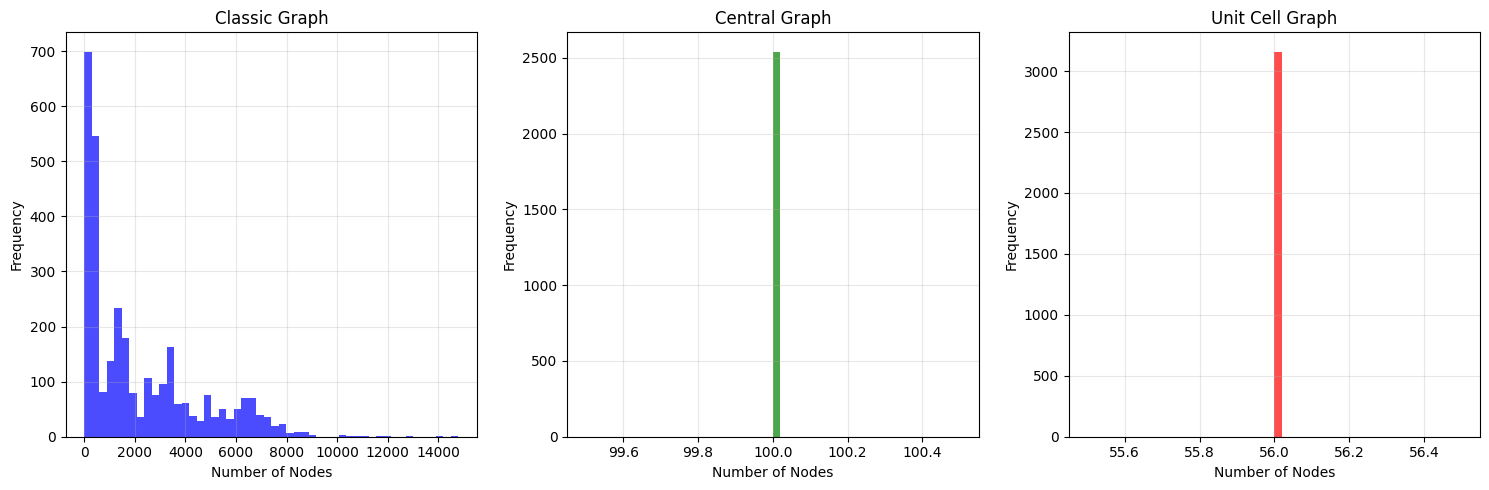

In [6]:
# Import plotting library
import matplotlib.pyplot as plt

# Create figure with subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot classic graph histogram
ax1.hist(statistics_classic['# of nodes'], bins=50, alpha=0.7, color='blue')
ax1.set_xlabel('Number of Nodes')
ax1.set_ylabel('Frequency') 
ax1.set_title('Classic Graph')
ax1.grid(True, alpha=0.3)

# Plot central graph histogram
ax2.hist(statistics_central['# of nodes'], bins=50, alpha=0.7, color='green')
ax2.set_xlabel('Number of Nodes')
ax2.set_ylabel('Frequency')
ax2.set_title('Central Graph')
ax2.grid(True, alpha=0.3)

# Plot unit cell graph histogram
ax3.hist(statistics_unit_cell['# of nodes'], bins=50, alpha=0.7, color='red')
ax3.set_xlabel('Number of Nodes')
ax3.set_ylabel('Frequency')
ax3.set_title('Unit Cell Graph')
ax3.grid(True, alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()



In [6]:
# Print first 3 points from training set
for i in range(3):
    data = dataset.train_set[i]
    print(data.y['xPDF'][1::2, :])
    print(data.y['n_atoms'])

tensor([], size=(0, 2, 6000))
100
tensor([], size=(0, 2, 6000))
45
tensor([], size=(0, 2, 6000))
100


In [7]:
print("Shape of data.y['xPDF']:", data.y['xPDF'].shape)

Shape of data.y['xPDF']: torch.Size([1, 2, 6000])


In [8]:
if data.y['xPDF'].numel() > 0:
    print("First few elements:", data.y['xPDF'][:5])

First few elements: tensor([[[ 0.0000e+00,  1.0000e-02,  2.0000e-02,  ...,  5.9970e+01,
           5.9980e+01,  5.9990e+01],
         [ 0.0000e+00, -3.1064e-03, -6.4045e-03,  ...,  1.1742e-04,
           1.2855e-04,  1.4275e-04]]])


In [9]:
print("Keys in data.y:", data.y.keys())

Keys in data.y: dict_keys(['crystal_type', 'space_group_symbol', 'space_group_number', 'crystal_system', 'crystal_system_number', 'atomic_species', 'n_atomic_species', 'np_size', 'n_atoms', 'n_bonds', 'cell_params', 'unit_cell_x', 'unit_cell_edge_index', 'unit_cell_edge_attr', 'unit_cell_pos_abs', 'unit_cell_pos_frac', 'unit_cell_n_atoms', 'unit_cell_n_bonds', 'nd', 'xrd', 'nPDF', 'xPDF', 'sans', 'saxs'])


In [10]:
print("All data:", data.y['xPDF'][:, :])
print("First elements:", data.y['xPDF'][0::2, :])

All data: tensor([[[ 0.0000e+00,  1.0000e-02,  2.0000e-02,  ...,  5.9970e+01,
           5.9980e+01,  5.9990e+01],
         [ 0.0000e+00, -3.1064e-03, -6.4045e-03,  ...,  1.1742e-04,
           1.2855e-04,  1.4275e-04]]])
First elements: tensor([[[ 0.0000e+00,  1.0000e-02,  2.0000e-02,  ...,  5.9970e+01,
           5.9980e+01,  5.9990e+01],
         [ 0.0000e+00, -3.1064e-03, -6.4045e-03,  ...,  1.1742e-04,
           1.2855e-04,  1.4275e-04]]])


torch.Size([1, 2, 6000])


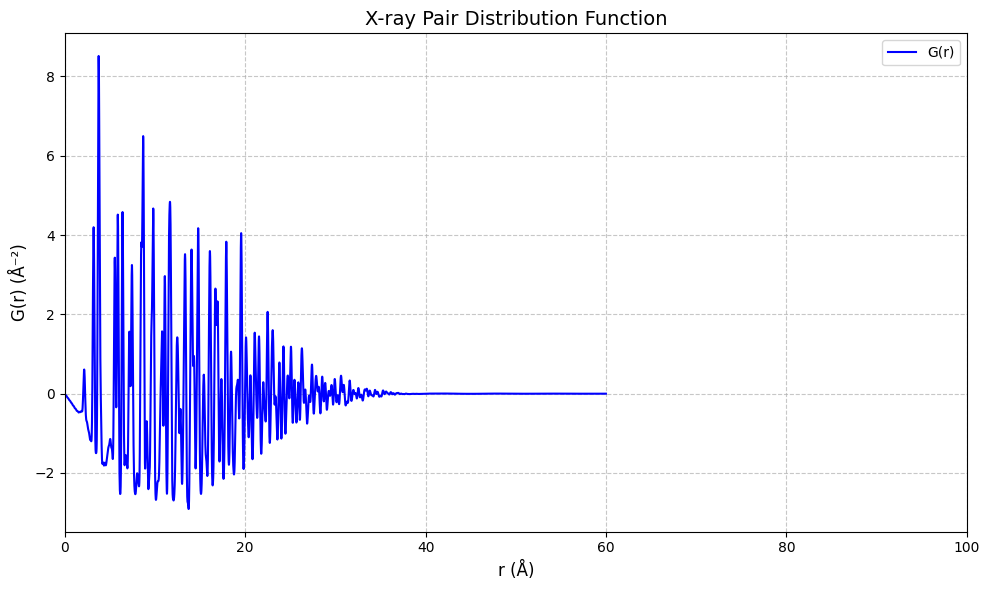

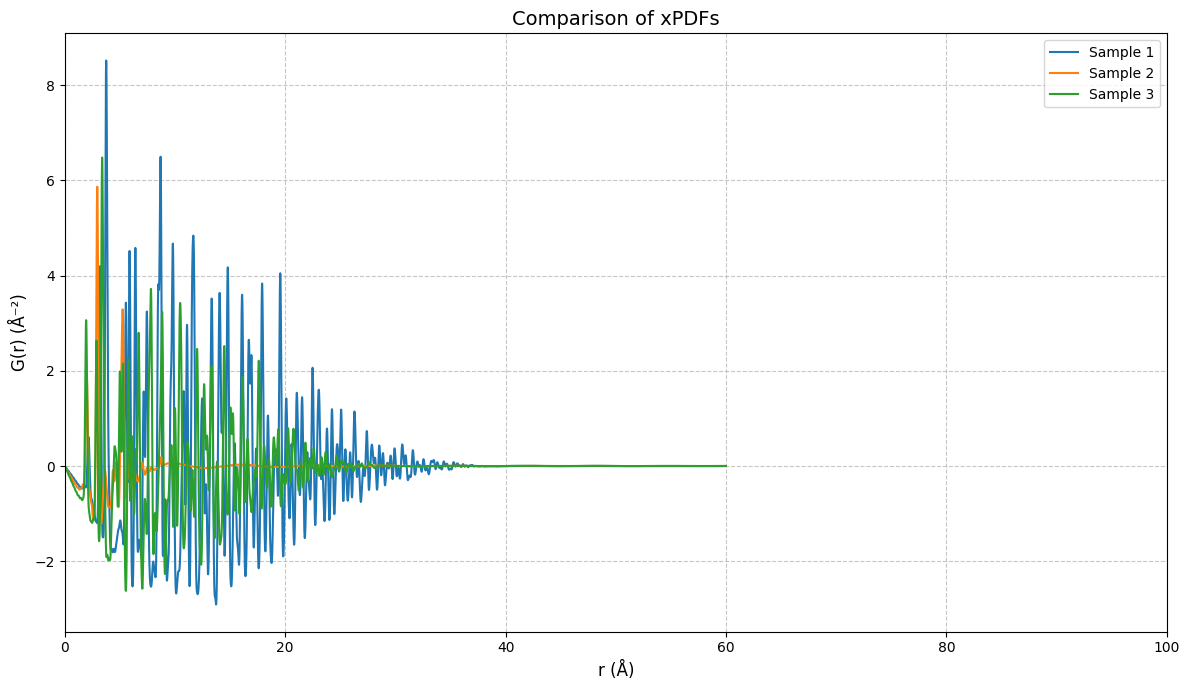

In [11]:
from visualize_xpdf import plot_xpdf, plot_multiple_xpdfs

# Plot a single xPDF
data_point = dataset.train_set[0]
print(data_point.y['xPDF'].shape)
plot_xpdf(data_point.y['xPDF'])

# Plot multiple xPDFs
xpdfs = [dataset.train_set[i].y['xPDF'] for i in range(50)]
labels = ['Sample 1', 'Sample 2', 'Sample 3']
plot_multiple_xpdfs(xpdfs, labels=labels)

In [1]:
import encoder

# Create MLP encoder
encoder_mlp = encoder.Encoder(input_dim=6000, hidden_dim=1024, output_dim=784, num_layers=4, type='MLP')

# Create Transformer encoder 
encoder_transformer = encoder.Encoder(input_dim=6000, hidden_dim=1024, output_dim=784, num_layers=4, type='Transformer')

# Create CNN encoder
encoder_cnn = encoder.Encoder(input_dim=6000, hidden_dim=1024, output_dim=784, num_layers=4, type='CNN')



